# Problem Sets: Gravitational Wave Turbulence Kernels

These problems test understanding of the core physics and numerical methods in this codebase.  
Each problem asks you to **implement** a function from scratch (without looking at the source), then verify it against the existing implementation.

**Setup:** run the cell below before any problem set.

In [1]:
import sys
sys.path.insert(0, "src")

import numpy as np
import matplotlib.pyplot as plt
import mpmath as mp
from scipy import integrate, special
from functools import lru_cache

# Reference implementations (for verification only — don't peek until you're done!)
import gw_turbulence.core as ref

print("Setup complete.")

Setup complete.


---
## Problem Set 1 — Foundations

### P1.1: The Geometric Kernel

The GW stress-energy tensor kernel from Gogoberidze et al. (2007) Appendix A is:

$$B(p, x, y) = 54 - 2p^2 x^{3/2} - 2p^2 y^{3/2} + p^4 x^{3/2} y^{3/2} + x^{-3/2} y^{3/2} + y^{-3/2} x^{3/2}$$

where $p = k/k_0$, $x = k_1^{-4/3}$, $y = u^{-4/3}$ in the Gogoberidze substitution variables.

**Tasks:**
- **(a)** Implement `my_kernel_bracket(p, x, y)`.
- **(b)** Verify `kernel_bracket(0, 1, 1)` = 56 by hand: with $p=0$, only the last two terms survive: $x^{-3/2}y^{3/2} + y^{-3/2}x^{3/2} = 1\cdot1 + 1\cdot1 = 2$, plus the constant 54. ✓
- **(c)** Verify `kernel_bracket(1, 1, 1)` = 53 by hand.
- **(d)** Check against the reference implementation.

In [4]:
def my_kernel_bracket(p: float, x: float, y: float) -> float:
    x32 = x**(3/2)
    y32 = y**(3/2)
    xm32 = x**(-3/2)
    ym32 = y**(-3/2)
    return 54 - 2 * p **2 * x32 - 2 * p **2 * y32 + p**4 * x32 * y32 + xm32 * y32 + ym32*x32

In [5]:
# --- Verification ---
assert abs(my_kernel_bracket(0, 1, 1) - 56.0) < 1e-10, f"Expected 56, got {my_kernel_bracket(0,1,1)}"
assert abs(my_kernel_bracket(1, 1, 1) - 53.0) < 1e-10, f"Expected 53, got {my_kernel_bracket(1,1,1)}"

# Compare against reference over a grid of (p, x, y) values
for p, x, y in [(0.5, 0.8, 1.2), (1.0, 0.5, 2.0), (1.5, 1.0, 0.3)]:
    mine = my_kernel_bracket(p, x, y)
    theirs = ref.kernel_bracket(p, x, y)
    assert abs(mine - theirs) < 1e-10, f"Mismatch at p={p},x={x},y={y}: {mine} vs {theirs}"

print("P1.1 passed!")

P1.1 passed!


### P1.2: The Monochromatic Geometric Kernel $K_0(p)$

When the turbulent energy spectrum is a delta function $E(k) = E_0\,\delta(k-k_0)$, the wavevector integration collapses to $k_1 = u = k_0$. The remaining geometric factor is:

$$K_0(p) = \frac{14}{3} - \frac{p^2}{3} + \frac{p^4}{12}$$

**Tasks:**
- **(a)** Implement `my_K0_p(p)`.
- **(b)** Verify $K_0(0) = 14/3$. What does this represent physically?
- **(c)** Compute $K_0(2)$ exactly. Is it zero?
- **(d)** Find the value of $p$ at which $K_0(p)$ is maximized.

In [6]:
def my_K0_p(p: float) -> float:
    return 14/3 - p**2/3 + p**4/12

K0(0) = 4.666667  (expected 4.666667)
K0(2) = 4.666667  (is it zero? No)


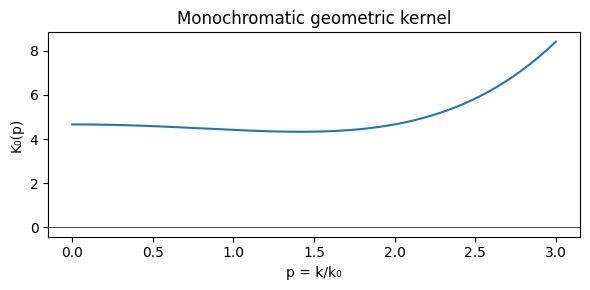

Maximum K0 at p = 3.000
P1.2 passed!


In [10]:
# --- Verification ---
assert abs(my_K0_p(0) - 14/3) < 1e-12, f"K0(0) should be 14/3 = {14/3:.6f}"

for p_test in [0.0, 0.5, 1.0, 1.5, 2.0]:
    assert abs(my_K0_p(p_test) - ref.K0_p(p_test)) < 1e-12, f"Mismatch at p={p_test}"

# (b) Analytical check
print(f"K0(0) = {my_K0_p(0):.6f}  (expected {14/3:.6f})")
print(f"K0(2) = {my_K0_p(2):.6f}  (is it zero? {'Yes' if abs(my_K0_p(2)) < 1e-10 else 'No'})")

# (d) Plot K0(p) and find the maximum
p_arr = np.linspace(0, 3, 300)
K0_arr = np.array([my_K0_p(p) for p in p_arr])
plt.figure(figsize=(6, 3))
plt.plot(p_arr, K0_arr)
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('p = k/k₀')
plt.ylabel('K₀(p)')
plt.title('Monochromatic geometric kernel')
plt.tight_layout()
plt.show()
print(f"Maximum K0 at p = {p_arr[np.argmax(K0_arr)]:.3f}")
print("P1.2 passed!")

### P1.3: The Kraichnan Decorrelation Kernel (Closed Form)

For the monochromatic spectrum with **Kraichnan** (stationary) decorrelation:

$$H(p, \Omega) = \frac{K_0(p)}{p} \cdot \Theta(2-p) \cdot \exp\!\left(-\frac{\Omega^2}{2\pi}\right)$$

where $\Theta$ is the Heaviside step function and $\Omega = \omega/\eta_0$.

**Tasks:**
- **(a)** Implement `my_H_delta_k_kraichnan(p, Omega)` — must work on arrays.
- **(b)** Verify the Heaviside cutoff: $H(p > 2, \Omega) = 0$. Why does the triangle inequality impose $k \leq 2k_0$?
- **(c)** What is the characteristic frequency $\Omega^*$ where $H$ drops to $e^{-1}$ of its peak?
- **(d)** Plot $H(p, \Omega=0)$ vs $p$ and $H(p=1, \Omega)$ vs $\Omega$.

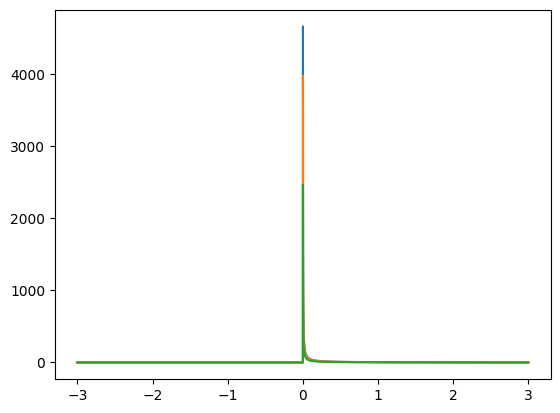

In [76]:
def my_H_delta_k_kraichnan(p :float, Omega, cutoff =2):
    k0 = my_K0_p(p)
    Omega = np.asarray(Omega,dtype=float)

    result = np.where((p>0) & (p<=cutoff), 
                      k0 / p * np.exp(-Omega**2/(2 * np.pi)),0.0
                      )
    return result
p = np.arange(-3,3,0.001)
list = [my_H_delta_k_kraichnan(pt,[0,1,2]) for pt in p ]

plt.plot(p,list)
plt.show()

Characteristic frequency Omega* = sqrt(2π) = 2.5066


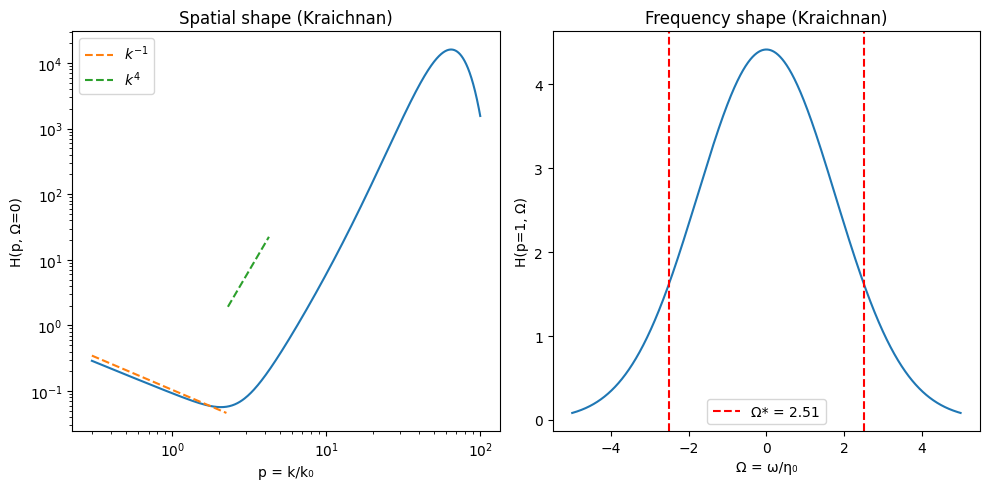

P1.3 passed!


In [82]:
# --- Verification ---
assert my_H_delta_k_kraichnan(2.5, 0.0) == 0.0,  "Triangle inequality violated: p>2 must give 0"
assert my_H_delta_k_kraichnan(-1.0, 0.0) == 0.0, "p<=0 must give 0"
assert my_H_delta_k_kraichnan(1.0, 0.0) > 0,     "Inside triangle must be positive"

p_arr  = np.linspace(0.3, 100.0, 2000)
Om_arr = np.linspace(-5, 5, 2000)

mine_p  = my_H_delta_k_kraichnan(p_arr, 0.0, cutoff= 2)
ref_p   = ref.H_delta_k_kraichnan(p_arr, 0.0)
assert np.allclose(mine_p, ref_p, rtol=1e-10), "p-sweep mismatch"

mine_Om = my_H_delta_k_kraichnan(1.0, Om_arr)
ref_Om  = ref.H_delta_k_kraichnan(1.0, Om_arr)
assert np.allclose(mine_Om, ref_Om, rtol=1e-10), "Omega-sweep mismatch"

# (c) Characteristic frequency
Omega_star = np.sqrt(2 * np.pi)   # exp(-Omega^2/(2pi)) = 1/e => Omega^2/(2pi)=1 => Omega=sqrt(2pi)
print(f"Characteristic frequency Omega* = sqrt(2π) = {Omega_star:.4f}")

# (d) Plots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
new = my_H_delta_k_kraichnan(p_arr,Omega=Om_arr,cutoff=100)
axes[0].loglog(p_arr, new)
axes[0].loglog(p_arr[:40], 1.2 * new[0] * p_arr[0] * p_arr[:40]**(-1), "--", label = r"$k^{-1}$")
axes[0].loglog(p_arr[40:80 ], 0.8 * new[0] * p_arr[0] * p_arr[40:80]**(4), "--", label = r"$k^{4}$")
axes[0].set_xlabel('p = k/k₀'); axes[0].set_ylabel('H(p, Ω=0)')
axes[0].set_title('Spatial shape (Kraichnan)')
axes[0].legend()
axes[1].plot(Om_arr, mine_Om)
axes[1].axvline(Omega_star, color='r', ls='--', label=f'Ω* = {Omega_star:.2f}')
axes[1].axvline(-Omega_star, color='r', ls='--')
axes[1].set_xlabel('Ω = ω/η₀'); axes[1].set_ylabel('H(p=1, Ω)')
axes[1].set_title('Frequency shape (Kraichnan)')
axes[1].legend()
plt.tight_layout(); plt.show()
print("P1.3 passed!")

---
## Problem Set 2 — Integration Infrastructure

### P2.1: Integration Bounds from the Triangle Inequality

In Gogoberidze variables, $x = (k_1/k_0)^{-4/3}$ so $\tilde{k}_1 = x^{-3/4}$. For given $p = k/k_0$ and outer-scale ratio $R$, the triangle inequality gives:

$$u \in \bigl[\max(|\tilde{k}_1 - p|,\, 1),\; \min(\tilde{k}_1 + p,\, R^{3/4})\bigr]$$

Converting $u \to y = u^{-4/3}$: $y_{\min} = u_{\max}^{-4/3}$, $y_{\max} = u_{\min}^{-4/3}$.

**Tasks:**
- **(a)** Implement `my_integration_bounds(x, p, R)` returning `(y_min, y_max)` or `None`.
- **(b)** Check for `p=1.5, R=100, x=1.0` — verify the arithmetic by hand.
- **(c)** For what values of `x` does the function return `None`? Plot the valid `x` range for `p=0.1, R=1e4`.

In [93]:
def my_integration_bounds(x: float, p: float, R: float):
    xm34 = x**(-3/4)
    umin = np.max((np.abs(xm34 -p),
                    1))
    umax = np.min((xm34 +p,
                     R **(3/4)))

    if  umin < umax :
        return (umax ** (-4/3), umin ** (-4/3))
    return None

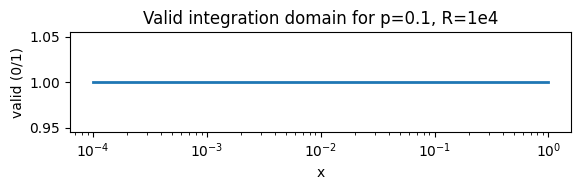

P2.1 passed! Valid range: x ∈ [1.000e-04, 1.000e+00]


In [94]:
# --- Verification ---
result = my_integration_bounds(x=1.0, p=1.5, R=100)
assert result is not None, "Should be non-trivial for these parameters"
y_min, y_max = result
assert y_min < y_max, f"y_min={y_min} must be < y_max={y_max}"

# Compare against reference over many (x, p, R) combinations
for x, p, R in [(1.0, 0.5, 1e4), (0.5, 1.0, 1e3), (0.1, 0.1, 100), (0.001, 2.0, 1e4)]:
    mine = my_integration_bounds(x, p, R)
    theirs = ref._integration_bounds(x, p, R)
    if mine is None:
        assert theirs is None, f"Reference returned {theirs} but mine returned None at x={x},p={p},R={R}"
    else:
        assert theirs is not None
        assert np.allclose(mine, theirs, rtol=1e-12), f"Mismatch: {mine} vs {theirs}"

# (c) Plot valid x range for p=0.1, R=1e4
x_vals = np.geomspace(1e-4, 1.0, 500)
valid = [my_integration_bounds(x, 0.1, 1e4) is not None for x in x_vals]
plt.figure(figsize=(6, 2))
plt.semilogx(x_vals, valid, lw=2)
plt.xlabel('x'); plt.ylabel('valid (0/1)')
plt.title('Valid integration domain for p=0.1, R=1e4')
plt.tight_layout(); plt.show()
print(f"P2.1 passed! Valid range: x ∈ [{x_vals[valid][0]:.3e}, {x_vals[valid][-1]:.3e}]")

### P2.2: Cosine-Spaced Grid

Near singularities, uniform grids are inaccurate. A **cosine grid** on $[a, b]$ clusters points near both endpoints:

$$t_i = a + \frac{b-a}{2}\bigl(1 - \cos(\pi\,i/(N-1))\bigr), \quad i = 0, \ldots, N-1$$

**Tasks:**
- **(a)** Implement `my_cosine_grid(lower, upper, count)` returning an `np.ndarray`.
- **(b)** Verify endpoints exactly: `grid[0] == lower`, `grid[-1] == upper`.
- **(c)** Compare point density near endpoints between cosine and uniform grids for $N=20$.
- **(d)** Explain why endpoint clustering improves trapezoid-rule accuracy for singular integrands.

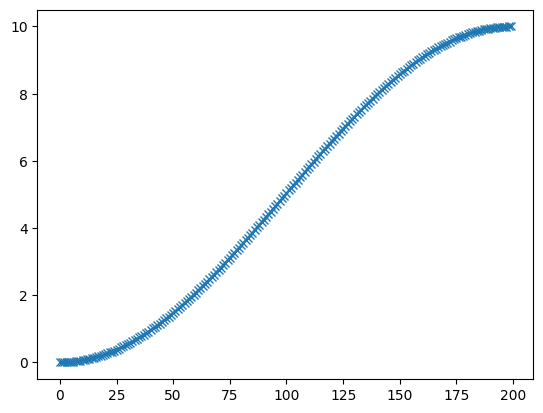

In [127]:
def my_cosine_grid(lower: float, upper: float, count: int) -> np.ndarray:
    c = np.arange(count)
    out = np.zeros(count)
    for i in c:
        val = lower  + (upper -lower)/2 * ( 1 - np.cos(np.pi * i/(count -1)))
        out[i] = val


    return out

abra = my_cosine_grid(0,10,200)

plt.plot(abra, "-x"); plt.show()


Points in [0, 0.1]: cosine=4, uniform=2


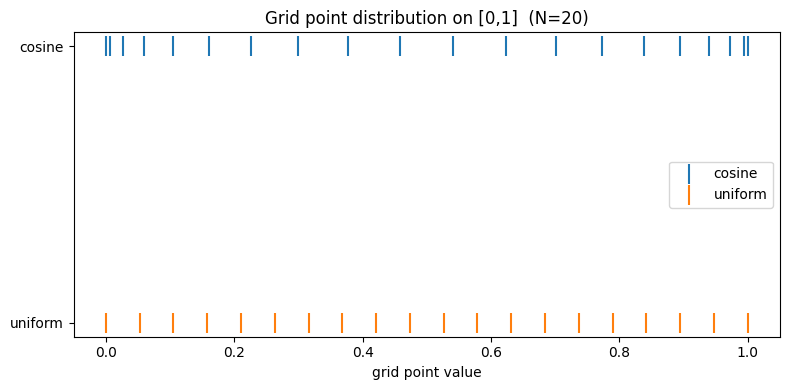

P2.2 passed!


In [132]:
# --- Verification ---
g = my_cosine_grid(2.0, 5.0, 50)
assert abs(g[0] - 2.0) < 1e-12, "First point must equal lower"
assert abs(g[-1] - 5.0) < 1e-12, "Last point must equal upper"
assert len(g) == 50
assert np.all(np.diff(g) > 0), "Grid must be strictly increasing"

# Compare against reference
ref_g = ref._cosine_grid(2.0, 5.0, 50)
assert np.allclose(g, ref_g, rtol=1e-12)

# (c) Point density comparison
N = 20
cosine_g = my_cosine_grid(0.0, 1.0, N)
uniform_g = np.linspace(0.0, 1.0, N)
n_cos = np.sum(cosine_g <= 0.1)
n_uni = np.sum(uniform_g <= 0.1)
print(f"Points in [0, 0.1]: cosine={n_cos}, uniform={n_uni}")

plt.figure(figsize=(8, 4))
plt.scatter(cosine_g, np.ones_like(cosine_g), marker='|', s=200, label='cosine')
plt.scatter(uniform_g, np.ones_like(uniform_g)*0, marker='|', s=200, label='uniform')
plt.yticks([0, 1], ['uniform', 'cosine'])
plt.xlabel('grid point value')
plt.title('Grid point distribution on [0,1]  (N=20)')
plt.legend(); plt.tight_layout(); plt.show()
print("P2.2 passed!")

### P2.3: Singular Interval Decomposition

The temporal convolution $\int g(q_1)\,g(q-q_1)\,dq_1$ has integrable singularities at $q_1 = 0$ and $q_1 = q$. The domain $[-q_{\text{bound}}, q_{\text{bound}}]$ is split to exclude small windows of width $\delta$ around these points.

**Tasks:**
- **(a)** Implement `my_conv_intervals(q, q_bound, split_width)` → list of `(lower, upper)` tuples.
- **(b)** For `q=2.0, q_bound=5.0, split_width=0.1`, enumerate all intervals by hand.
- **(c)** Handle the edge case `q=0`: singular points coincide — only one gap should appear.
- **(d)** Handle `q > 2*q_bound`: the second singular point is outside the domain.

In [ ]:
def my_conv_intervals(q: float, q_bound: float, split_width: float):

In [ ]:
# --- Verification ---

# (b) Standard case: q=2.0 — singular points at 0 and 2.0
intervals = my_conv_intervals(q=2.0, q_bound=5.0, split_width=0.1)
total_covered = sum(hi - lo for lo, hi in intervals)
expected_covered = 10.0 - 0.2 - 0.2   # two gaps of width 0.2
print(f"Intervals: {intervals}")
assert abs(total_covered - expected_covered) < 1e-10, f"Expected coverage {expected_covered}, got {total_covered}"

# (c) q=0: singular points coincide → only one gap
intervals_q0 = my_conv_intervals(q=0.0, q_bound=5.0, split_width=0.1)
total_q0 = sum(hi - lo for lo, hi in intervals_q0)
print(f"q=0 intervals: {intervals_q0}")
assert abs(total_q0 - (10.0 - 0.2)) < 1e-10, "Only one gap when q=0"

# (d) q outside domain: only one gap (at 0)
intervals_far = my_conv_intervals(q=100.0, q_bound=5.0, split_width=0.1)
total_far = sum(hi - lo for lo, hi in intervals_far)
print(f"q=100 intervals: {intervals_far}")
assert abs(total_far - (10.0 - 0.2)) < 1e-10, "Only one gap when q is outside domain"

# Compare against reference
for q_test, qb, sw in [(2.0, 5.0, 0.1), (0.0, 3.0, 0.05), (1.5, 4.0, 0.01), (50.0, 5.0, 0.1)]:
    mine = my_conv_intervals(q_test, qb, sw)
    theirs = ref._conv_intervals(q_test, qb, sw)
    mine_cov = sum(b-a for a,b in mine)
    their_cov = sum(b-a for a,b in theirs)
    assert abs(mine_cov - their_cov) < 1e-9, f"Coverage mismatch at q={q_test}: {mine_cov} vs {their_cov}"

print("P2.3 passed!")

---
## Problem Set 3 — Decaying Turbulence

### P3.1: The Decaying Temporal Kernel $g(q)$

For turbulence with energy decaying as $E(t) \propto (1 + t/\tau_1)^{-2/3}$, the Fourier-space temporal kernel is:

$$g(q) = e^{iq} \cdot (-iq)^{-5/3} \cdot \gamma\!\left(\tfrac{1}{3},\,-iq\right)$$

where $\gamma(a, z)$ is the **lower** incomplete gamma function and $q = \omega\tau_1$.

**Tasks:**
- **(a)** Implement `my_g_decaying_scalar(z: complex)` using `mpmath.gammainc`.
- **(b)** Show that $|g(q)| \sim q^{-5/3}$ for large real $q$ (power-law tail).
- **(c)** Plot $\text{Re}[g(q)]$ and $\text{Im}[g(q)]$ for $q \in [0.01, 30]$.
- **(d)** Verify $|g(q)| \cdot q^{5/3}$ approaches a constant as $q \to \infty$.

In [137]:
def my_g_decaying_scalar(z: complex) -> complex:
    """Implement me using mpmath.gammainc.
    Hint: g(q) = exp(iq) * (-iq)^(-5/3) * gamma_lower(1/3, -iq)
    In mpmath: mp.gammainc(a, z) returns the lower incomplete gamma gamma(a,z).
    """
    return np.exp(1j * z) * ( -1j * z) ** (-5/3) * mp.gammainc(1/3, -1j * z)

In [139]:
# --- Verification ---
val = my_g_decaying_scalar(1.0+0j)
ref_val = ref._g_decaying_scalar(1.0+0j)
assert abs(val - ref_val) / abs(ref_val) < 1e-6, f"Mismatch: {val} vs {ref_val}"

for z_test in [0.5+0j, 2.0+0j, 5.0+0j, 1.0+1j]:
    mine = my_g_decaying_scalar(z_test)
    theirs = ref._g_decaying_scalar(z_test)
    assert abs(mine - theirs) / (abs(theirs) + 1e-30) < 1e-5, f"Mismatch at z={z_test}: {mine} vs {theirs}"

# (b) & (d) Power-law tail check
q_large = np.array([10.0, 30.0, 100.0, 300.0])
g_vals = np.array([abs(my_g_decaying_scalar(q+0j)) for q in q_large])
scaled = np.absolute( g_vals * q_large**(5/3))
print("q^(5/3) * |g(q)|:", np.round(scaled, 3), " — should converge to a constant")
assert np.std(scaled) / np.mean(scaled) < 0.2, "Ratio should be nearly constant (within 20%)"

# (c) Plot
q_arr = np.linspace(0.05, 30, 400)
g_arr = np.array([my_g_decaying_scalar(q+0j) for q in q_arr])
plt.figure(figsize=(8, 3))
plt.plot(q_arr, g_arr.real, label='Re[g(q)]')
plt.plot(q_arr, g_arr.imag, label='Im[g(q)]')
plt.xlabel('q = ωτ₁'); plt.ylabel('g(q)')
plt.title('Decaying temporal kernel g(q)')
plt.legend(); plt.tight_layout(); plt.show()
print("P3.1 passed!")

TypeError: loop of ufunc does not support argument 0 of type mpf which has no callable rint method

### P3.2: Temporal Convolution for the Decaying Model

The GW spectrum from decaying turbulence requires the convolution:

$$C(q) = \int_{-\infty}^{\infty} dq_1 \;\text{Re}\bigl[g(q_1) \cdot g(q - q_1)\bigr]$$

computed numerically over a truncated domain $[-q_{\text{bound}}, q_{\text{bound}}]$.

**Tasks:**
- **(a)** Implement `my_temporal_conv_decay(q, q_bound=None, split_width=None, n_points=200)` using `my_cosine_grid`, `my_conv_intervals`, and `np.trapz`.
- **(b)** Verify $C(q) > 0$ everywhere (it represents a power spectrum).
- **(c)** Plot $C(q)$ for $q \in [0.1, 20]$ and compare qualitatively to the Kraichnan Gaussian.
- **(d)** Check that $C(0) > C(5)$ (decays from peak).

In [ ]:
def my_g_decaying(z):
    """Vectorized wrapper — reuse my_g_decaying_scalar."""
    if np.isscalar(z):
        return my_g_decaying_scalar(complex(z))
    arr = np.asarray(z)
    out = np.empty(arr.shape, dtype=complex)
    for idx, val in np.ndenumerate(arr):
        out[idx] = my_g_decaying_scalar(complex(val))
    return out


def my_temporal_conv_decay(q: float, q_bound=None, split_width=None, n_points: int = 200) -> float:
    """Implement me using my_cosine_grid, my_conv_intervals, and np.trapz."""
    raise NotImplementedError

In [ ]:
# --- Verification ---
c0 = my_temporal_conv_decay(q=0.0)
c5 = my_temporal_conv_decay(q=5.0)
assert c0 > 0, "C(0) must be positive"
assert c5 > 0, "C(5) must be positive"
assert c0 > c5, "C should decay from its peak"

# Compare against reference
for q_test in [0.1, 1.0, 5.0, 10.0]:
    mine = my_temporal_conv_decay(q_test)
    theirs = ref._temporal_conv_decay(q_test)
    rel_err = abs(mine - theirs) / (abs(theirs) + 1e-30)
    assert rel_err < 0.05, f"Relative error {rel_err:.3f} too large at q={q_test}: {mine} vs {theirs}"

# (c) Plot: decaying conv vs Kraichnan Gaussian
q_arr = np.linspace(0.1, 20, 60)
C_arr = np.array([my_temporal_conv_decay(q) for q in q_arr])
gaussian = np.exp(-q_arr**2 / (2*np.pi))   # Kraichnan shape (same variable name Omega -> q)

plt.figure(figsize=(7, 3))
plt.semilogy(q_arr, C_arr / C_arr[0], label='Decaying C(q) [normalized]')
plt.semilogy(q_arr, gaussian / gaussian[0], '--', label='Kraichnan Gaussian [normalized]')
plt.xlabel('q'); plt.ylabel('normalized temporal factor')
plt.title('Decaying vs Kraichnan temporal factors')
plt.legend(); plt.tight_layout(); plt.show()
print("P3.2 passed!")

### P3.3: Monochromatic Decaying Kernel $H_{\delta k,\,\text{decay}}$

The full monochromatic decaying kernel combines the geometric factor with the temporal convolution:

$$H(p, q) = \frac{K_0(p)}{p} \cdot \Theta(2-p) \cdot C(q)$$

**Tasks:**
- **(a)** Implement `my_H_delta_k_decay(p, q)`.
- **(b)** The $p$-dependence is identical to the Kraichnan model. What changes between the two models?
- **(c)** For fixed $p=1$, compare `my_H_delta_k_decay` and `my_H_delta_k_kraichnan` on the same axes. Which has heavier tails?
- **(d)** Implement a grid version that computes $C(q)$ **once per q value** for efficiency.

In [ ]:
def my_H_delta_k_decay(p: float, q: float) -> float:
    """Implement me!"""
    raise NotImplementedError


def my_H_delta_k_decay_grid(ps, qs, n_points: int = 200) -> np.ndarray:
    """Implement a grid version that computes C(q) once per q (not once per (p,q) pair)."""
    raise NotImplementedError

In [ ]:
# --- Verification ---
assert my_H_delta_k_decay(0.0, 1.0) == 0.0, "p=0 must give 0"
assert my_H_delta_k_decay(2.5, 1.0) == 0.0, "p>2 must give 0"
assert my_H_delta_k_decay(1.0, 1.0) > 0,    "p=1 must be positive"

for p_t, q_t in [(0.5, 0.1), (1.0, 2.0), (1.5, 5.0)]:
    mine = my_H_delta_k_decay(p_t, q_t)
    theirs = ref.H_delta_k_decay(p_t, q_t)
    rel_err = abs(mine - theirs) / (abs(theirs) + 1e-30)
    assert rel_err < 0.05, f"Error {rel_err:.3f} at p={p_t},q={q_t}: {mine} vs {theirs}"

# (c) Tail comparison
q_arr = np.linspace(0.1, 15, 60)
H_decay_arr   = np.array([my_H_delta_k_decay(1.0, q)         for q in q_arr])
H_kraich_arr  = np.array([my_H_delta_k_kraichnan(1.0, q)     for q in q_arr])

plt.figure(figsize=(7, 3))
plt.semilogy(q_arr, H_decay_arr  / H_decay_arr[0],  label='H_decay (decaying)')
plt.semilogy(q_arr, H_kraich_arr / H_kraich_arr[0], '--', label='H_kraichnan (Gaussian)')
plt.xlabel('q'); plt.ylabel('H(p=1, q) [normalized]')
plt.title('Decaying vs Kraichnan — tail comparison at p=1')
plt.legend(); plt.tight_layout(); plt.show()

# (d) Grid efficiency test
ps_small = np.linspace(0.1, 1.9, 5)
qs_small = np.linspace(0.1, 5.0, 5)
grid = my_H_delta_k_decay_grid(ps_small, qs_small)
assert grid.shape == (len(qs_small), len(ps_small))
print("P3.3 passed!")

---
## Problem Set 4 — The Full Kolmogorov Model

### P4.1: The Stationary Integrand `integrand_y`

For the full Kolmogorov spectrum with Kraichnan decorrelation, the inner integrand is:

$$f(y;\,x,p,q,M) = y^{3/4}\,(x+y)^{-1/2}\,x^{3/4}\cdot B(p,x,y)\cdot \exp\!\left(-\frac{2xy}{x+y}\frac{q^2}{M^2}\right)\cdot\text{erfc}\!\left(-\frac{\sqrt{2}\,q}{M\sqrt{x+y}}\right)$$

**Tasks:**
- **(a)** Implement `my_integrand_y(y, x, p, q, M)` using `my_kernel_bracket` and `scipy.special.erfc`.
- **(b)** For $q=0$: `exp(0)=1` and `erfc(0)=1`. Verify this limiting behavior.
- **(c)** Verify that the integrand decays rapidly as $q \to \infty$ for fixed $x, y$.
- **(d)** Check the sign convention: for what argument does `erfc(-z) → 2` as $z \to +\infty$?

In [ ]:
def my_integrand_y(y: float, x: float, p: float, q: float, M: float) -> float:
    """Implement me! Use my_kernel_bracket and scipy.special.erfc."""
    raise NotImplementedError

In [ ]:
# --- Verification ---
val_q0 = my_integrand_y(y=1.0, x=1.0, p=0.5, q=0.0, M=1.0)
assert val_q0 > 0, "Integrand at q=0 must be positive"

val_large_q = my_integrand_y(y=1.0, x=1.0, p=0.5, q=100.0, M=1.0)
assert val_large_q < val_q0 * 1e-3, "Integrand should decay rapidly with q"

# Compare against reference
for y, x, p, q, M in [(1.0, 1.0, 0.5, 0.0, 1.0),
                       (0.5, 0.8, 1.0, 2.0, 0.5),
                       (2.0, 0.3, 0.1, 1.0, 1.0)]:
    mine = my_integrand_y(y, x, p, q, M)
    theirs = ref.integrand_y(y, x, p, q, M)
    assert abs(mine - theirs) / (abs(theirs) + 1e-30) < 1e-9, f"Mismatch at y={y},x={x},p={p},q={q},M={M}: {mine} vs {theirs}"

# (d) erfc sign convention
print(f"erfc(-10) = {special.erfc(-10):.6f}  (should be ~2)")
print(f"erfc(+10) = {special.erfc(+10):.2e}   (should be ~0)")
print("P4.1 passed!")

### P4.2: The $p \to 0$ Analytic Limit $H_{k0}$

When $k \to 0$, the full 2D integral simplifies to:

$$H_{k0}(q) = \frac{7\,M^3\,k_0^{-4}}{16\,\pi^{3/2}} \int_{R^{-1}}^{1} x^{11/4}\,e^{-q^2 x/M^2}\,\text{erfc}\!\left(-\frac{q\sqrt{x}}{M}\right) dx$$

**Tasks:**
- **(a)** Implement `my_H_k0_analytic(q, M=1.0, k0=1.0, R=1e4)` using `scipy.integrate.quad`.
- **(b)** Verify the output is positive and decays for large $q$.
- **(c)** Compare to `H_pq(p=1e-4, q, ...)` — what relative error do you observe?
- **(d)** Show the $M^3$ scaling: `H_k0(q, M=0.1) / H_k0(q, M=1.0)` should equal `0.001`.

In [ ]:
def my_H_k0_analytic(q, M: float = 1.0, k0: float = 1.0, R: float = 1e4):
    """Implement me! Works on scalar or array q."""
    raise NotImplementedError

In [ ]:
# --- Verification ---
q_arr = np.array([0.1, 0.5, 1.0, 2.0, 5.0])
mine_arr  = my_H_k0_analytic(q_arr, M=1.0)
ref_arr   = ref.H_k0_analytic(q_arr, M=1.0)

assert np.all(mine_arr > 0), "All values must be positive"
assert np.allclose(mine_arr, ref_arr, rtol=1e-5), "Mismatch with reference"

# (d) M^3 scaling
ratio = my_H_k0_analytic(1.0, M=0.1) / my_H_k0_analytic(1.0, M=1.0)
print(f"H_k0(M=0.1)/H_k0(M=1.0) = {ratio:.6f}  (expected {0.1**3:.6f})")
assert abs(ratio - 0.1**3) < 1e-6 * 0.1**3, "M^3 scaling violated"

# (c) Comparison to full H_pq at p→0 (slow!)
q_test = 1.0
H_analytic  = my_H_k0_analytic(q_test, M=1.0, R=1e4)
H_full      = ref.H_pq(p=1e-4, q=q_test, M=1.0, R=1e4)
rel_err = abs(H_analytic - H_full) / H_full
print(f"H_k0_analytic vs H_pq(p=1e-4): relative error = {rel_err:.4f}")

# Plot spectrum
q_plot = np.geomspace(0.01, 20, 80)
H_plot = my_H_k0_analytic(q_plot)
plt.figure(figsize=(6,3))
plt.loglog(q_plot, H_plot)
plt.xlabel('q'); plt.ylabel('H_k0(q)')
plt.title('p→0 analytic spectrum (Kraichnan)')
plt.tight_layout(); plt.show()
print("P4.2 passed!")

### P4.3: The Full $H(p, q)$ Prefactor and Assembly

The overall normalization is:

$$\text{prefactor}(p, M, k_0) = \frac{3\,M^3\,k_0^{-4}}{256\,(2\pi)^{3/2}\,p}$$

**Tasks:**
- **(a)** Implement `my_h_prefactor(p, M, k0)` with a floor `p_floor = max(p, 1e-10)`.
- **(b)** Explain why $H \propto 1/p$ at small $p$ is physically correct (think $\Omega_{GW}(k) \propto k H(k,\omega)$).
- **(c)** Verify the $M^3$ scaling numerically.
- **(d)** Assemble `my_H_pq(p, q, M=1.0, R=1e6, k0=1.0)` using `my_h_prefactor`, `my_integration_bounds`, `my_integrand_y`, and nested `scipy.integrate.quad`.

In [ ]:
def my_h_prefactor(p: float, M: float, k0: float) -> float:
    """Implement me!"""
    raise NotImplementedError


def my_H_pq(p: float, q: float, M: float = 1.0, R: float = 1e6,
             k0: float = 1.0, epsabs: float = 1e-8, epsrel: float = 1e-6) -> float:
    """Implement me! Chain together: my_h_prefactor + nested quad over x then y."""
    raise NotImplementedError

In [ ]:
# --- Verification ---

# (a) Prefactor
for p, M, k0 in [(0.5, 1.0, 1.0), (1.0, 0.5, 2.0), (1e-10, 1.0, 1.0)]:
    mine   = my_h_prefactor(p, M, k0)
    theirs = ref._h_prefactor(p, M, k0)
    assert abs(mine - theirs) / (abs(theirs) + 1e-30) < 1e-12, f"Prefactor mismatch at p={p}"

# (c) M^3 scaling of prefactor
ratio_pref = my_h_prefactor(1.0, M=0.1, k0=1.0) / my_h_prefactor(1.0, M=1.0, k0=1.0)
assert abs(ratio_pref - 0.001) < 1e-10, f"M^3 scaling: expected 0.001, got {ratio_pref}"
print(f"M^3 scaling of prefactor: {ratio_pref:.6f} (expected 0.001)")

# (d) Full H_pq (this may take ~10 seconds)
print("Computing H_pq(p=0.5, q=1.0) ... (may take a few seconds)")
mine_H   = my_H_pq(p=0.5, q=1.0, M=1.0, R=1e4)
theirs_H = ref.H_pq(p=0.5, q=1.0, M=1.0, R=1e4)
rel_err  = abs(mine_H - theirs_H) / theirs_H
print(f"H_pq: mine={mine_H:.6e}, ref={theirs_H:.6e}, rel_err={rel_err:.4f}")
assert mine_H > 0
assert rel_err < 0.01, "Relative error should be below 1%"
print("P4.3 passed!")

---
## Problem Set 5 — White-Noise Spatial Model

### P5.1: The White-Noise Geometric Kernel

For $\delta^3(r)$ spatial correlations, working directly with $z = k_1/k_0$ and $y = u/k_0$:

$$K_{zy}(p,z,y) = 54 - \frac{2p^2}{z^2} - \frac{2p^2}{y^2} + \frac{p^4}{z^2 y^2} + \frac{z^2}{y^2} + \frac{y^2}{z^2}$$

**Tasks:**
- **(a)** Implement `my_kernel_bracket_zy(p, z, y)`.
- **(b)** Verify that `kernel_bracket_zy(p, x^{-3/4}, y^{-3/4})` equals `kernel_bracket(p, x, y)`. What is the relationship between the two forms?
- **(c)** Show analytically that $K_{zy}(0, z, y) = z^2/y^2 + y^2/z^2$, and verify numerically.

In [ ]:
def my_kernel_bracket_zy(p: float, z: float, y: float) -> float:
    """Implement me!"""
    raise NotImplementedError

In [ ]:
# --- Verification ---
for p, z, y in [(0.5, 1.0, 1.5), (1.0, 2.0, 0.8), (0.0, 1.0, 2.0)]:
    mine   = my_kernel_bracket_zy(p, z, y)
    theirs = ref.kernel_bracket_zy(p, z, y)
    assert abs(mine - theirs) < 1e-10, f"Mismatch at p={p},z={z},y={y}: {mine} vs {theirs}"

# (b) Verify relationship between kernel_bracket_zy and kernel_bracket
# kernel_bracket(p, x, y) with x=(k1/k0)^(-4/3), y=(u/k0)^(-4/3)
# => z = k1/k0 = x^(-3/4), zy = u/k0 = y^(-3/4)
for x_var, y_var in [(1.0, 0.5), (0.8, 1.2), (0.3, 2.0)]:
    z_var = x_var**(-0.75)
    zy_var = y_var**(-0.75)
    kbzy = my_kernel_bracket_zy(0.5, z_var, zy_var)
    kb   = ref.kernel_bracket(0.5, x_var, y_var)
    print(f"kernel_bracket_zy(0.5, x^(-3/4), y^(-3/4)) = {kbzy:.6f}, kernel_bracket(0.5, x, y) = {kb:.6f}")

# (c) p=0 limit
z_t, y_t = 2.0, 0.5
expected_p0 = z_t**2/y_t**2 + y_t**2/z_t**2
computed_p0 = my_kernel_bracket_zy(0.0, z_t, y_t)
assert abs(computed_p0 - expected_p0) < 1e-10, f"p=0 limit: {computed_p0} vs {expected_p0}"
print(f"p=0 check: K_zy(0,{z_t},{y_t}) = {computed_p0:.6f}, expected = {expected_p0:.6f}")
print("P5.1 passed!")

### P5.2: White-Noise Spatial Integral

The 2D spatial integral:

$$S(p, R) = \int_1^{R^{3/4}} \frac{z}{p}\,dz \int_{\max(|p-z|,\,1)}^{\min(p+z,\,R^{3/4})} y\,K_{zy}(p,z,y)\,dy$$

**Tasks:**
- **(a)** Implement `my_white_spatial_integral(p, R)` with nested `scipy.integrate.quad`.
- **(b)** Verify the $y$ bounds from the triangle inequality $|k - k_1| \leq u \leq k + k_1$.
- **(c)** For $R=100, p=1.5$, compute what fraction of the integral comes from $z \in [1, 2]$ vs $z \in [2, R^{3/4}]$.
- **(d)** Explain why the white-noise Kraichnan kernel `H = exp(-Ω²/(2π)) * S(p,R)` factorizes perfectly, but the full Kolmogorov kernel does not.

In [ ]:
def my_white_spatial_integral(p: float, R: float,
                               epsabs: float = 1e-4, epsrel: float = 1e-3) -> float:
    """Implement me!"""
    raise NotImplementedError

In [ ]:
# --- Verification ---
for p_t, R_t in [(0.5, 1e3), (1.0, 1e4), (1.5, 100)]:
    mine   = my_white_spatial_integral(p_t, R_t)
    theirs = ref._white_spatial_integral(p_t, R_t)
    rel_err = abs(mine - theirs) / (abs(theirs) + 1e-30)
    assert rel_err < 0.01, f"Error {rel_err:.4f} at p={p_t},R={R_t}: {mine} vs {theirs}"

# (c) Fraction from z in [1,2] vs [2, R^(3/4)]
R_test, p_test = 100.0, 1.5
Rd34 = R_test**0.75

def outer_z(z, p, R, p_floor=None):
    p_floor = p_floor or max(p, 1e-10)
    y_lo = max(abs(p_floor - z), 1.0)
    y_hi = min(p_floor + z, R**0.75)
    if y_lo >= y_hi:
        return 0.0
    def inner_y(y):
        return y * ref.kernel_bracket_zy(p_floor, z, y)
    val, _ = integrate.quad(inner_y, y_lo, y_hi, epsabs=1e-4, epsrel=1e-3, limit=200)
    return z / p_floor * val

part_low,  _ = integrate.quad(outer_z, 1.0,  2.0,  args=(p_test, R_test), limit=200)
part_high, _ = integrate.quad(outer_z, 2.0,  Rd34, args=(p_test, R_test), limit=200)
total = part_low + part_high
print(f"z∈[1,2]:       {part_low:.4e}  ({100*part_low/total:.1f}%)")
print(f"z∈[2,R^(3/4)]: {part_high:.4e}  ({100*part_high/total:.1f}%)")
print("P5.2 passed!")

---
## Problem Set 6 — Challenge Problems

### P6.1: LRU Caching Strategy

The function `_g_decaying_scalar` uses `@lru_cache(maxsize=1024)` keyed on the exact complex argument.

**Tasks:**
- **(a)** For a `24×24` grid with `convolution_points=160`, estimate the total number of `g_decaying` calls and the expected cache hit rate.
- **(b)** Design a scenario where two logically-equivalent calls miss the cache due to floating-point arithmetic.
- **(c)** Instrument `_g_decaying_scalar` with a call counter and measure the actual hit rate on a small grid. Compare to your estimate.

In [ ]:
# (a) Estimate
# For each (x, y) pair in the 2D integration, the convolution calls g(q1) and g(q-q1)
# for n_points values of q1. With a 24x24 (x,y) grid and 160 convolution points:
x_points = 24
y_points = 24  
conv_points = 160
q_values = 24   # one row of the output grid

# Your estimate here:
total_calls_estimate = ???   # Fill in
print(f"Estimated total g_decaying calls: {total_calls_estimate:,}")

# (c) Instrument with call counter
call_count = {"hits": 0, "misses": 0}

# YOUR IMPLEMENTATION: wrap g_decaying_scalar with a counter
# Hint: use a dictionary as a manual cache to count hits vs misses

print("\nP6.1: fill in your analysis above")

### P6.2: MPI Row Distribution

The grid computation distributes rows across MPI ranks.

**Tasks:**
- **(a)** Implement `my_split_row_indices(n_rows, rank, size)` using round-robin: row $i$ → rank $i \bmod \text{size}$.
- **(b)** For `n_rows=10, size=3`, verify that every row appears exactly once across all ranks.
- **(c)** For `N_q=30, N_p=30, size=4`, compute total bytes transmitted in a gather (float64).
- **(d)** Is round-robin optimal when different rows have different compute costs? Propose a better strategy.

In [ ]:
def my_split_row_indices(n_rows: int, rank: int, size: int) -> list:
    """Round-robin: row i goes to rank i % size."""
    raise NotImplementedError

In [ ]:
# --- Verification ---
n_rows, size = 10, 3
all_assignments = []
for rank in range(size):
    rows = my_split_row_indices(n_rows, rank, size)
    print(f"  Rank {rank}: rows {rows}")
    all_assignments.extend(rows)

assert sorted(all_assignments) == list(range(n_rows)), "Each row must appear exactly once"

# Compare against reference
from gw_turbulence.mpi import split_row_indices as ref_split
for rank in range(size):
    mine   = sorted(my_split_row_indices(n_rows, rank, size))
    theirs = sorted(ref_split(n_rows, rank, size))
    assert mine == theirs, f"Rank {rank}: {mine} vs {theirs}"

# (c) Data transmitted in gather
Nq, Np, size_mpi = 30, 30, 4
bytes_per_rank = (Nq // size_mpi + 1) * Np * 8  # float64
total_bytes = bytes_per_rank * (size_mpi - 1)     # all ranks send to rank 0
print(f"\nApproximate bytes transmitted in gather: {total_bytes:,} bytes ({total_bytes/1024:.1f} KB)")

print("P6.2 passed!")

### P6.3: Numerical Stability at Singularities

The kernel $g(q_1)$ diverges as $q_1 \to 0$. In `integrand_y_decaying`, this is handled with a small imaginary perturbation: `z1 = split_width * 1j` when `q1 == 0`.

**Tasks:**
- **(a)** What is the order of the singularity? Find $\alpha$ such that $|g(q_1)| \sim |q_1|^\alpha$ as $q_1 \to 0$.
- **(b)** Verify that $\int_0^1 |g(q_1)|\,dq_1 < \infty$ (integrability), both analytically and numerically.
- **(c)** Explain why $g(i\varepsilon)$ is finite even though $g(0)$ diverges.
- **(d)** Compare accuracy of cosine grid (N=200) vs uniform grid (N=1000) for $\int_0^1 g(q_1)g(1-q_1)dq_1$ against the `quad` result.

In [ ]:
# (a) Order of singularity
small_q = np.array([0.001, 0.003, 0.01, 0.03, 0.1])
g_small = np.array([abs(ref.g_decaying(q)) for q in small_q])

# Fit alpha in |g(q)| ~ q^alpha via log-log regression
alpha_fit = np.polyfit(np.log(small_q), np.log(g_small), 1)[0]
print(f"Fitted singularity exponent alpha = {alpha_fit:.3f}  (expected: -5/3 ≈ {-5/3:.3f})")

# (b) Numerical integrability check
q1_arr = np.linspace(0.001, 1.0, 2000)   # avoid exact 0
g_arr  = np.array([abs(ref.g_decaying(q)) for q in q1_arr])
integral_approx = np.trapz(g_arr, q1_arr)
print(f"Numerical ∫₀¹ |g(q)| dq ≈ {integral_approx:.4f}  (should be finite)")

# (c) Small imaginary perturbation
eps = 1e-6
g_imag_eps = ref.g_decaying(1j * eps)
print(f"g(i·eps) = {g_imag_eps}  (finite despite g(0) diverging)")

# (d) Accuracy comparison
from scipy import integrate as sci_int

def integrand_conv(q1):
    return (ref.g_decaying(q1) * ref.g_decaying(1.0 - q1)).real

# Reference: quad result (high accuracy)
q1_quad, _ = sci_int.quad(integrand_conv, 0.001, 0.999, limit=200)
print(f"\nReference (quad): {q1_quad:.8f}")

# Cosine grid N=200
q1_cos = ref._cosine_grid(0.001, 0.999, 200)
cos_val = np.trapz([integrand_conv(q) for q in q1_cos], q1_cos)
print(f"Cosine grid N=200: {cos_val:.8f}  error={abs(cos_val - q1_quad):.2e}")

# Uniform grid N=1000
q1_uni = np.linspace(0.001, 0.999, 1000)
uni_val = np.trapz([integrand_conv(q) for q in q1_uni], q1_uni)
print(f"Uniform grid N=1000: {uni_val:.8f}  error={abs(uni_val - q1_quad):.2e}")

print("\nP6.3: analysis complete")

### P6.4: Dimensional Analysis and Physical Units

**Tasks:**
- **(a)** The Kraichnan decorrelation rate at scale $k_0$ is $\eta_0 = (\varepsilon^{1/3}/\sqrt{2\pi})\,k_0^{2/3}$. Express the dimensionless frequency $\Omega = \omega/\eta_0$ in physical units.
- **(b)** In `integrand_y`, the exponential argument is $-2xy/(x+y) \cdot q^2/M^2$. Show this equals $-2\tilde{k}_1^2\tilde{u}^2/(\tilde{k}_1^2+\tilde{u}^2) \cdot q^2/M^2$.
- **(c)** The GW energy density is $\Omega_{GW}(k) \propto k^4 H(k, \omega\!=\!0)$. Given $H \propto M^3 k_0^{-4}/p$, what $k$-scaling do you predict for $\Omega_{GW}$?
- **(d)** Verify the $k_0^{-4}$ scaling numerically: compute `H_pq(1.0, 1.0, k0=1.0)` and `H_pq(1.0, 1.0, k0=2.0)` and check the ratio equals $2^{-4} = 0.0625$.

In [ ]:
# (a) Physical interpretation
print("(a) eta_0 = (eps^(1/3) / sqrt(2pi)) * k0^(2/3)")
print("    Omega = omega / eta_0 = omega * sqrt(2pi) / (eps^(1/3) * k0^(2/3))")
print("    This is the ratio of GW frequency to turbulent eddy-turnover rate at scale k0")

# (b) Show the exponent in integrand_y equals the harmonic-mean form
# x = k1^(-4/3)  =>  k1 = x^(-3/4)  (tilde_k1)
# y = u^(-4/3)   =>  u  = y^(-3/4)  (tilde_u)
# 2xy/(x+y) = 2 * k1^(-4/3) * u^(-4/3) / (k1^(-4/3) + u^(-4/3))
# In terms of k1, u: = 2/(k1^(4/3) + u^(4/3)) ... verify numerically
x_t, y_t = 0.5, 1.2
tilde_k1 = x_t**(-0.75)
tilde_u  = y_t**(-0.75)
form1 = 2*x_t*y_t / (x_t + y_t)
form2 = 2 / (tilde_k1**(-4/3) + tilde_u**(-4/3))
print(f"\n(b) 2xy/(x+y) = {form1:.6f},  2/(k1^(-4/3)+u^(-4/3)) = {form2:.6f}")
assert abs(form1 - form2) < 1e-12

# (c) Omega_GW ~ k^4 * H(k) ~ k^4 * k0^(-4)/p ~ k^4/(k0^4 * k/k0) = k^3/k0^3
print("\n(c) Omega_GW(k) ∝ k^4 * (M^3 k0^(-4) / p) = k^4 * (M^3 k0^(-4) / (k/k0)) = M^3 k^3 / k0^3")
print("    => Omega_GW ∝ k^3 (in units of k0) for the Kolmogorov power-law spectrum")

# (d) k0^(-4) scaling (this call may take ~30 seconds)
print("\n(d) Computing k0^(-4) scaling ... (may take ~30s)")
H_k0_1 = ref.H_pq(p=1.0, q=1.0, M=1.0, k0=1.0, R=1e4)
H_k0_2 = ref.H_pq(p=1.0, q=1.0, M=1.0, k0=2.0, R=1e4)
ratio_k0 = H_k0_2 / H_k0_1
print(f"H(k0=2)/H(k0=1) = {ratio_k0:.6f}  (expected {2**(-4):.6f} = 2^(-4))")
assert abs(ratio_k0 - 2**(-4)) < 0.01, "k0^(-4) scaling violated"

print("\nP6.4 complete!")

---
## Summary Scorecard

| Problem | Function | Difficulty | Status |
|---------|----------|------------|--------|
| P1.1 | `kernel_bracket` | ⭐ | |
| P1.2 | `K0_p` | ⭐ | |
| P1.3 | `H_delta_k_kraichnan` | ⭐⭐ | |
| P2.1 | `_integration_bounds` | ⭐⭐ | |
| P2.2 | `_cosine_grid` | ⭐ | |
| P2.3 | `_conv_intervals` | ⭐⭐ | |
| P3.1 | `g_decaying` | ⭐⭐⭐ | |
| P3.2 | `_temporal_conv_decay` | ⭐⭐⭐ | |
| P3.3 | `H_delta_k_decay` + grid | ⭐⭐ | |
| P4.1 | `integrand_y` | ⭐⭐ | |
| P4.2 | `H_k0_analytic` | ⭐⭐ | |
| P4.3 | `_h_prefactor` + `H_pq` | ⭐⭐⭐ | |
| P5.1 | `kernel_bracket_zy` | ⭐ | |
| P5.2 | `_white_spatial_integral` | ⭐⭐⭐ | |
| P6.1 | Cache analysis | ⭐⭐ | |
| P6.2 | `split_row_indices` + MPI | ⭐⭐ | |
| P6.3 | Singularity analysis | ⭐⭐⭐ | |
| P6.4 | Dimensional analysis | ⭐⭐⭐ | |